<a href="https://colab.research.google.com/github/nicolagherardi/AI_course_test/blob/main/Assignment_3_Gherardi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Revealing representative "typical" day-types using traffic data observation and clustering

Clustering is a way of letting the data tell us its own story. Instead of assuming traffic always follows the same daily rhythm, we will use clustering to discover “typical day-types”: weekdays, weekends, holidays, incidents, straight from sensor observations. By the end of this exercise, you will learn how to prepare temporal data for clustering, explore it and reflect on what the patterns might mean for managing roads in practice.

Objective: find, evaluate and choose a clustering of daily time-series (day-profiles), and show how that clustering helps a simple prediction task.

what this notebook does:

Data loading & Exploratory Data Analysis (visualize raw day profiles).
Preprocessing
Baseline experiments (k-means), time-series alternatives (k-Shape or DTW), and at least one density/soft model (GMM/DBSCAN).
Internal evaluation (silhouette, Calinski-Harabasz, Davies-Bouldin) + stability checks.
Time-aware external evaluation using the centroid-based historical-mean predictor (RMSE, MAPE).
Interpretation: centroids, representative days and weekday distribution
Glossary
day-profile / day-matrix: one row = one day; columns = 5-minute buckets.
centroid historical-mean predictor: for each cluster, predict a day by using the cluster centroid (or average of historical days assigned to that cluster).

## Data preparation

In [ ]:
import pandas as pd
import numpy as np
#upload the dataset by downloading both datasets from canvas and upload it on colab

data_df = pd.read_csv("dataset_exercise_5_clustering_highway_traffic.csv",sep=";")
data_df

,PORTAL,Date,time_from,time_to,Interval_5,SPEED_MS_AVG,flow
0,"E4S 56,780",20210101,00:00:00,00:05:00,0,18.56,39
1,"E4S 56,780",20210101,00:05:00,00:10:00,1,20.39,18
2,"E4S 56,780",20210101,00:10:00,00:15:00,2,19.27,26
3,"E4S 56,780",20210101,00:15:00,00:20:00,3,19.52,52
4,"E4S 56,780",20210101,00:20:00,00:25:00,4,20.52,52
...,...,...,...,...,...,...,...
104838,"E4S 56,780",20211231,23:35:00,23:40:00,283,19.58,115
104839,"E4S 56,780",20211231,23:40:00,23:45:00,284,19.47,87
104840,"E4S 56,780",20211231,23:45:00,23:50:00,285,19.77,130
104841,"E4S 56,780",20211231,23:50:00,23:55:00,286,18.79,129


The provided dataset contains 5-minute observations on one highway microwave sensor and needs to be in a format ready for clustering. Clustering doesn’t work on raw tables, it needs a structured representation. In this section, we will take the raw sensor data and reformat it so that each entire day becomes a single data vector. This makes it possible to compare whole days against each other.

Here’s the logic: a day is 24 hours long, and with 5-minute measurements that means 288 data points. If we line these up in order, we can represent each day as a 288-dimensional vector: one row per day, one column per time slot. Later, clustering will group these day-vectors into families of “similar days.” This is "giving every day its own fingerprint."

In [ ]:
# Sort the DataFrame 'data_df' by columns "Date" and "Interval_5"
data_df.sort_values(["Date", "Interval_5"])

# Extract unique dates from the sorted DataFrame
days = np.unique(data_df[['Date']].values.ravel())
# Calculate the total number of unique days
ndays = len(days)

# Group the DataFrame 'data_df' by the "Date" column
day_subsets_df = data_df.groupby(["Date"])

# Define the total number of 5-minute intervals in a day
nintvals = 288

# Create a matrix 'vectorized_day_dataset' filled with NaN values
vectorized_day_dataset = np.zeros((ndays, nintvals))
vectorized_day_dataset.fill(np.nan)

# Loop through each unique day
for i in range(0, ndays):
    # Get the DataFrame corresponding to the current day
    df_t = day_subsets_df.get_group(days[i])

    # Loop through each row in the current day's DataFrame
    for j in range(len(df_t)):
        # Get the current day's DataFrame
        df_t = day_subsets_df.get_group(days[i])

        # Extract the "Interval_5" and "flow" values and populate 'vectorized_day_dataset'
        vectorized_day_dataset[i, df_t.iloc[j]["Interval_5"]] = df_t.iloc[j]["flow"]

# Print the resulting 'vectorized_day_dataset'
print(vectorized_day_dataset)

/tmp/ipykernel_742/2050002240.py:22: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  df_t = day_subsets_df.get_group(days[i])
/tmp/ipykernel_742/2050002240.py:27: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  df_t = day_subsets_df.get_group(days[i])


[[ 39.  18.  26. ...  32.  39.  34.]
 [ 30.  32.  27. ...  44.  41.  39.]
 [ 36.  44.  52. ...  50.  45.  23.]
 ...
 [ 20.  34.  31. ...  38.  42.  36.]
 [ 36.  40.  25. ...  38.  56.  35.]
 [ 33.  32.  34. ... 130. 129. 117.]]


Recap of the steps the code did:

STEP 1:We sorted the data to guarantee chronological order.
STEP 2:We pulled out all unique days, so we know how many daily profiles we need.
STEP 3:We fixed the number of time slots (288) so every day has the same length.
STEP 4:We built a big empty matrix, one row per day, one column per 5-minute slot.
STEP 5:Finally, we filled this matrix: for each day, we inserted the flow values into the right time slots.
The result: a clean “day × time” dataset ready for clustering. From here on, each row can be treated like a single point in a 288-dimensional space.

Note that if you plan to reveal network-wide day-types (more sensors), this day vector can be ordered vector of SENSORS * TIME-INTERVALS.

# Part 1: Data exploration

# 1.1 : Missing values and outliers

Before we trust this matrix, we need to explore it. Clustering algorithms are very sensitive to missing values and outliers: a single "bad day" can distort entire clusters. Let’s check for gaps and anomalies before we hand the data to the clustering algorithm.

In [ ]:

print('number of nans',np.sum(np.isnan(vectorized_day_dataset)))
print('rate of nans',np.sum(np.isnan(vectorized_day_dataset))/(ndays*nintvals))

number of nans 277
rate of nans 0.0026350837138508373


The quick check shows only 277 missing entries, which is just 0.26% of the data. That is very low but missingness is rarely random. In traffic data, it could mean times when no vehicles were detected (night hours) or moments when sensors temporarily failed. Spotting where/when these gaps happen helps us decide whether to ignore them, fill them in or treat them as a signal themselves.

(288,)


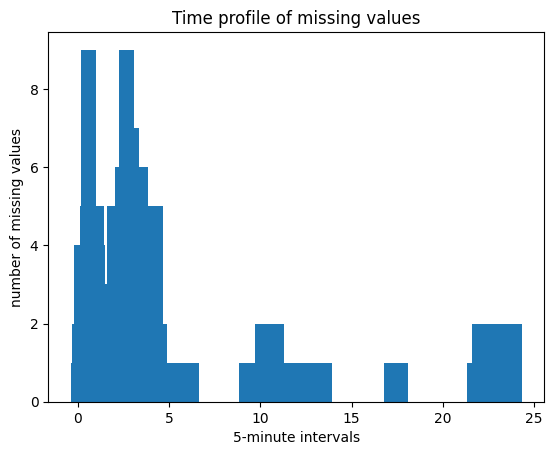

In [ ]:
nans_per_time = np.sum(np.isnan(vectorized_day_dataset),0)
print(nans_per_time.shape)

import matplotlib.pyplot as plt

fig, ax = plt.subplots()
# Create an array 'x_axis' representing the 5-minute intervals
x_axis = np.arange(0, nintvals, 1, dtype=int)
# Initialize an empty list 'x_axis_hours' to store time values in hours
x_axis_hours = []
# Convert interval indices to hours and append them to 'x_axis_hours'
for i in range(0, len(x_axis)):
  x_axis_hours.append(float(x_axis[i]*5)/60)
ax.bar(x_axis_hours,height=nans_per_time)


ax.set_ylabel('number of missing values')
ax.set_xlabel('5-minute intervals')
ax.set_title('Time profile of missing values')

plt.show()

Are these missing values associated with just a few days?

In [ ]:
nans_per_day = np.sum(np.isnan(vectorized_day_dataset),1)
print('number of days with missing value',np.size(np.where(nans_per_day > 0),1))

number of days with missing value 28


# Part 1.2 : Daily profile of flow dynamic

Visualizing traffic flow across time of day reveals the heartbeat of the system. What does the data look like? What is the traffic pattern? You should expect sharp rises around commuting hours and dips overnight. These daily profiles are important because clustering algorithms will later decide “similarity” based on the shapes of these curves. When you see peaks or irregular bumps, think about what real world behaviors they correspond to: work commute, evening leisure, freight transport.

Below is the script that can help you visualize all days where overlapping transparencies highlight some patterns. The black line is the average yearly flow for a time interval.

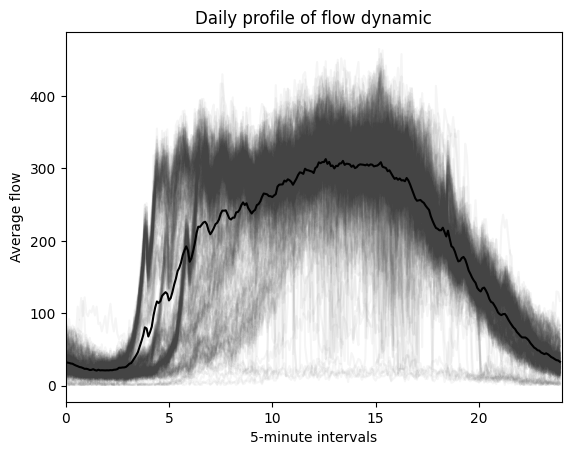

In [ ]:
# Create a new figure and axis object using subplots
fig, ax = plt.subplots()# a convenient way to create a new figure and a set of subplots.
ax.plot(np.array([x_axis_hours,]*ndays).transpose(),vectorized_day_dataset.transpose(),color='#444444',alpha=0.05)
# Above line plots the dataset with specified color and transparency.
ax.plot(x_axis_hours,np.transpose(np.nanmean(vectorized_day_dataset,0)),color='black')
# Above line plots the average of the dataset in black color.

ax.set_ylabel('Average flow')
ax.set_xlabel('5-minute intervals')
plt.xlim(0,24)
ax.set_title('Daily profile of flow dynamic')

plt.show()

Boxplots compress the daily data into distributions for each 5-minute slot. They tell us not only the average but also the spread and the outliers. Below is the code to visualize these boxplots

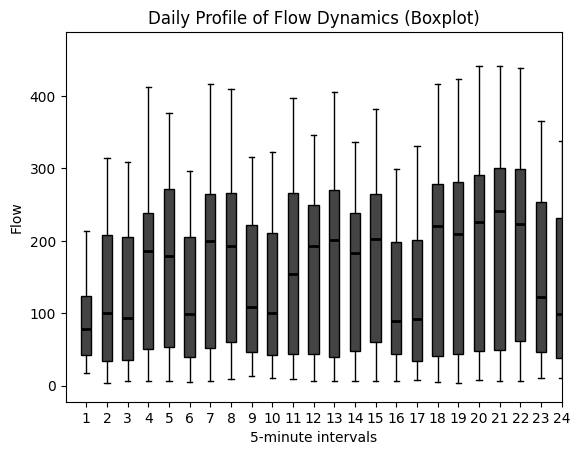

In [ ]:
# Create a new figure and axis object using subplots
fig, ax = plt.subplots()  # This line is a convenient way to create a new figure and a set of subplots.

# Create a boxplot for the dataset
boxplot = ax.boxplot(vectorized_day_dataset.T, patch_artist=True)

# Customize the boxplot appearance
for patch in boxplot['boxes']:
    patch.set_facecolor('#444444')  # Set the box color to gray
for median in boxplot['medians']:
    median.set(color='black', linewidth=2)  # Set median line color to black

# Set the y-axis label
ax.set_ylabel('Flow')

# Set the x-axis label
ax.set_xlabel('5-minute intervals')

# Set the x-axis limits to be between 0 and 24
plt.xlim(0, 24)

# Set the title of the plot
ax.set_title('Daily Profile of Flow Dynamics (Boxplot)')

# Display the plot
plt.show()

Notice whether morning peaks are tight (predictable) or wide (variable). Wide distributions could mean more “noise” for clustering, the algorithm will find it harder to decide what is typical for that time slot.

By averaging days into weekdays vs. weekends, we test a very human hypothesis: “Mondays don’t look like Sundays.” Do the curves confirm it? This step bridges human intuition (calendar categories) with machine learning exploration (clustering). Later, we’ll see whether the algorithm rediscovers these patterns or finds something subtler, like holiday effects.

In [ ]:
import datetime

# Create an array 'day_of_week' to store the day of the week for each unique date
day_of_week = np.zeros((ndays))

# Loop through each unique date
for i in range(0, ndays):
    # Parse the current date from a string to a datetime object
    day_dt = datetime.datetime.strptime(str(days[i]), '%Y%m%d')

    # Get the day of the week (1 for Monday, 2 for Tuesday, ..., 7 for Sunday)
    day_of_week[i] = day_dt.isoweekday()

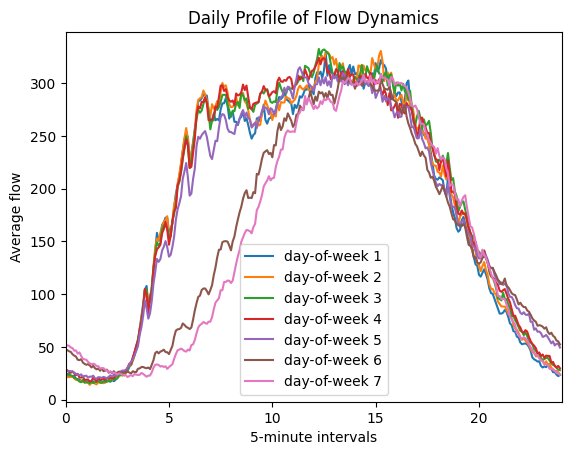

In [ ]:
# Create a new figure and axis object using subplots
fig, ax = plt.subplots()

# Iterate through each day of the week (from 1 to 7)
for i in range(1, 8):
    # Find the indices of days that correspond to the current day of the week
    day_of_week_index_t = np.where(day_of_week == i)

    # Calculate the number of days that match the current day of the week
    ndays_t = np.size(day_of_week_index_t[0])

    # Plot the average flow for the current day of the week
    ax.plot(x_axis_hours,
            np.nanmean(vectorized_day_dataset[day_of_week_index_t[0], :].transpose(), 1),
            label='day-of-week ' + str(i))
    # This line plots the average flow for the current day of the week.
    # 'np.nanmean()' calculates the mean while handling NaN values.

# Set the y-axis label
ax.set_ylabel('Average flow')

# Set the x-axis label
ax.set_xlabel('5-minute intervals')

# Set the x-axis limits to be between 0 and 24
plt.xlim(0, 24)

# Set the title of the plot
ax.set_title('Daily Profile of Flow Dynamics')

# Add a legend indicating the day of the week
ax.legend()

# Display the plot
plt.show()

The day's index is from 1 - 7, where 1 is Monday. To our expectations, we can see the difference between weekdays and weekends. So far, we’ve established that traffic days differ in systematic ways: weekday/weekend, time-of-day peaks, occasional anomalies. Clustering will now formalize these differences into groups. The goal is to let the algorithm discover with patterns that we might not have thought to test manually. This we explore with clustering in the next part of the exercise.

# Part 2: Clustering

In the previous section, we explored our data and prepared it for analysis. Now, we reach the core of our task: clustering. Our goal is to group similar days together to discover common daily traffic patterns, or "day-types."

We face a fundamental question in clustering: how many clusters (k) are there? There is no single "correct" answer; it depends on the story the data tells and our analytical goals. Once we have our clusters, we will visualize the resulting day-types (cluster centroids) and analyze their characteristics to understand what each "typical day" represents ( a weekday rush hour pattern, a quiet weekend pattern, incidents)

## Clustering

Using clustering methods in scikit-learn is relatively simple, as shown below. With one line of code, you can get some clusters. However, this will need some work to search for representative clusters. This is the first step to pattern exploration.

As you can see k-means clustering method can not handle missing values, so you have choices: impute data or remove them. We will just remove all days that have missing observations. Fewer days would be removed if we restrict the clustering to a particular day-time period, 06:00 - 22:00:00. Below, we prepare a new dataset without missing values and update the list of days for later visualization purposes.

In [ ]:
clusters = None
# print(np.where(nans_per_day > 0)[0])
vectorized_day_dataset_no_nans = vectorized_day_dataset[np.where(nans_per_day == 0)[0],:]
days_not_nans = days[np.where(nans_per_day == 0)[0]]

# Train/Validation sets split for the Advanced Track
I randomly split the training set into a training set and a validation set, with respectively 80% and 20% of the observations

In [ ]:
from sklearn.model_selection import train_test_split

# Splite the train and test data and also the corresponding days
x_train, x_valid, days_train, days_valid = train_test_split(
    vectorized_day_dataset_no_nans, days_not_nans, test_size=0.2, random_state=0
)

from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_valid_scaled = scaler.transform(x_valid)

The clustering methods considered were K-means, agglomerative clustering, Bisecting K-means, DBSCAN, OPTICS, and Gaussian Mixture Models (GMM), as seen during classes. Their main parameters were systematically explored using internal clustering metrics.

## K-means

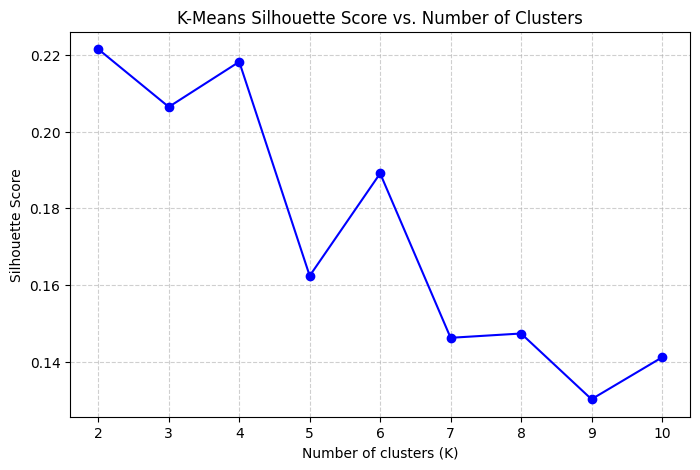

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

K_range = range(2, 11)
score_kmeans = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init="auto").fit(X_train_scaled)
    score_kmeans.append(silhouette_score(X_train_scaled, kmeans.labels_))

plt.figure(figsize=(8, 5))
plt.plot(K_range, score_kmeans, marker='o', linestyle='-', color='b')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.title('K-Means Silhouette Score vs. Number of Clusters')
plt.show()

# best_k_index = np.argmax(score_kmeans)
# n_cl_kmeans = K_range[best_k_index]
# print(f"Optimal number of clusters for K-Means (based on highest Silhouette Score): {n_cl_kmeans}")

## Agglomerative

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

n_clusters_range = range(2, 11)
metrics = ["euclidean", "manhattan"]

results_agg = []

for n_clusters in n_clusters_range:
    for metric in metrics:
            agg_clustering = AgglomerativeClustering(
                n_clusters=n_clusters, linkage="complete", metric=metric
            )
            labels = agg_clustering.fit_predict(X_train_scaled)

            if len(np.unique(labels)) > 1:
                silhouette = silhouette_score(X_train_scaled, labels)
                davies_bouldin = davies_bouldin_score(X_train_scaled, labels)
                calinski_harabasz = calinski_harabasz_score(X_train_scaled, labels)
            else:
                silhouette = np.nan
                davies_bouldin = np.nan
                calinski_harabasz = np.nan

            results_agg.append(
                {
                    "n_clusters": n_clusters,
                    "linkage": "complete",
                    "metric": metric,
                    "silhouette_score": silhouette,
                    "davies_bouldin_score": davies_bouldin,
                    "calinski_harabasz_score": calinski_harabasz,
                }
            )


agg_results_df = pd.DataFrame(results_agg)
agg_results_df_sorted = agg_results_df.dropna(
    subset=["silhouette_score"]
).sort_values(by="silhouette_score", ascending=False)

print("\nTable of results:")
print(agg_results_df_sorted.to_string(index=False))


Table of results:
 n_clusters  linkage    metric  silhouette_score  davies_bouldin_score  calinski_harabasz_score
          2 complete manhattan          0.571608              0.830303                29.128592
          3 complete manhattan          0.551875              0.455368                18.379869
          2 complete euclidean          0.547175              0.971916                29.828376
          3 complete euclidean          0.527447              0.617912                18.866592
          4 complete euclidean          0.261008              0.910976                33.462578
          5 complete euclidean          0.249428              0.757612                26.574463
          6 complete euclidean          0.243292              0.697502                22.439548
          4 complete manhattan          0.225866              0.969145                44.854574
          5 complete manhattan          0.216494              1.071409                50.450244
          7 complete 

The manhattan distance metric seems to achieve slightly higher levels of Silhouette score

## Divisive

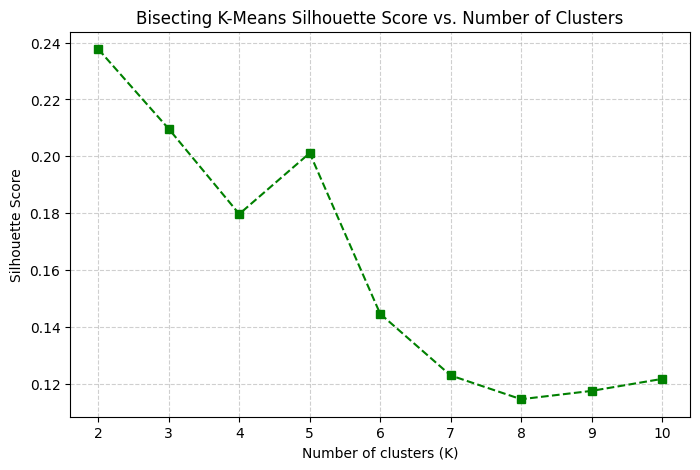

In [ ]:
from sklearn.cluster import BisectingKMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

score_divisive = []
for k in K_range:
    bisect_kmeans = BisectingKMeans(n_clusters=k, random_state=0).fit(X_train_scaled)
    score_divisive.append(silhouette_score(X_train_scaled, bisect_kmeans.labels_))

plt.figure(figsize=(8, 5))
plt.plot(K_range, score_divisive, marker='s', linestyle='--', color='g')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.title('Bisecting K-Means Silhouette Score vs. Number of Clusters')
plt.show()

# best_k_index_divisive = np.argmax(score_divisive)
# n_cl_divisive = K_range[best_k_index_divisive]
# print(f"Optimal number of clusters for Bisecting K-Means (based on highest Silhouette Score): {n_cl_divisive}")

The best Silhouette score is quite low, about 0.25, but we can notice a local peak corresponding to 5 clusters.

# DBSCAN

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN, OPTICS
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

fitted_models = {}
cluster_labels = {}

dbscan_results = []

# Define parameter ranges for DBSCAN
eps_range = [1, 11, 15, 20, 30, 40, 50, 100, 800]
min_samples_range = [2, 5, 10, 20, 30]

best_dbscan_silhouette = -1
best_dbscan_params = None
best_dbscan_labels = None
best_dbscan_model_instance = None

for eps_val in eps_range:
    for min_s in min_samples_range:
        dbscan = DBSCAN(eps=eps_val, min_samples=min_s)
        labels = dbscan.fit_predict(X_train_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        # Evaluate only if more than 1 cluster and not all points are noise or in one single cluster
        if n_clusters > 1 and len(np.unique(labels)) < len(X_train_scaled):
            silhouette = silhouette_score(X_train_scaled, labels)
            davies_bouldin = davies_bouldin_score(X_train_scaled, labels)
            calinski_harabasz = calinski_harabasz_score(X_train_scaled, labels)

            dbscan_results.append({
                "model": "DBSCAN",
                "eps": eps_val,
                "min_samples": min_s,
                "n_clusters": n_clusters,
                "silhouette_score": silhouette,
                "davies_bouldin_score": davies_bouldin,
                "calinski_harabasz_score": calinski_harabasz
            })

            if silhouette > best_dbscan_silhouette:
                best_dbscan_silhouette = silhouette
                best_dbscan_params = {"eps": eps_val, "min_samples": min_s}
                best_dbscan_labels = labels
                best_dbscan_model_instance = dbscan


dbscan_results_df = pd.DataFrame(dbscan_results)

dbscan_results_df_sorted = dbscan_results_df.sort_values(by="silhouette_score", ascending=False)
print("\nDBSCAN Results (sorted by Silhouette Score):")
print(dbscan_results_df_sorted.to_string(index=False))
if best_dbscan_params:
        #print(f"\nBest DBSCAN parameters: {best_dbscan_params} with Silhouette Score: {best_dbscan_silhouette:.4f}")
        fitted_models["DBSCAN"] = best_dbscan_model_instance
        cluster_labels["DBSCAN"] = best_dbscan_labels



DBSCAN Results (sorted by Silhouette Score):
 model  eps  min_samples  n_clusters  silhouette_score  davies_bouldin_score  calinski_harabasz_score
DBSCAN   30            2           2          0.551875              0.455368                18.379869
DBSCAN   20            2           2          0.451630              1.588967                16.899411
DBSCAN   15            2           2          0.254333              3.239556                11.444850
DBSCAN   11           10           3         -0.017905              2.125217                17.475240
DBSCAN   11            2          10         -0.020003              2.024537                12.758388
DBSCAN   11            5           8         -0.031032              2.244179                12.936414


The tested values of eps outside the range 11–40 did not produce a valid clustering, so further analysis was restricted to the values within this range. The most impacting value of the radius ranged between 20-30, always creating 2 clusters.

Labels -1 indicate outliers

# OPTICS

In [ ]:
optics_results = []

# Define parameter ranges for OPTICS
min_samples_range_optics = [5, 10, 20, 30, 40]
xi_range = [0.01, 0.05, 0.1, 0.2]
min_cluster_size_range = [5, 10, 20, 30]

best_optics_silhouette = -1
best_optics_params = None
best_optics_labels = None
best_optics_model_instance = None

for min_s_optics in min_samples_range_optics:
    for xi_val in xi_range:
        for min_cl_size in min_cluster_size_range:
            optics = OPTICS(min_samples=min_s_optics, xi=xi_val, min_cluster_size=min_cl_size)
            optics.fit(X_train_scaled)
            labels = optics.labels_

            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

            # Evaluate only if more than 1 cluster and not all points are noise or in one single cluster
            if n_clusters > 1 and len(np.unique(labels)) < len(X_train_scaled):
                silhouette = silhouette_score(X_train_scaled, labels)
                davies_bouldin = davies_bouldin_score(X_train_scaled, labels)
                calinski_harabasz = calinski_harabasz_score(X_train_scaled, labels)

                optics_results.append({
                    "model": "OPTICS",
                    "min_samples": min_s_optics,
                    "xi": xi_val,
                    "min_cluster_size": min_cl_size,
                    "n_clusters": n_clusters,
                    "silhouette_score": silhouette,
                    "davies_bouldin_score": davies_bouldin,
                    "calinski_harabasz_score": calinski_harabasz
                })

                if silhouette > best_optics_silhouette:
                    best_optics_silhouette = silhouette
                    best_optics_params = {"min_samples": min_s_optics, "xi": xi_val, "min_cluster_size": min_cl_size}
                    best_optics_labels = labels
                    best_optics_model_instance = optics

optics_results_df = pd.DataFrame(optics_results)
# Handle case where optics_results_df might be empty after filtering
if not optics_results_df.empty:
    optics_results_df_sorted = optics_results_df.sort_values(by="silhouette_score", ascending=False)
    print("\nOPTICS Results (sorted by Silhouette Score):")
    print(optics_results_df_sorted.to_string(index=False))

    if best_optics_params:
        #print(f"\nBest OPTICS parameters: {best_optics_params} with Silhouette Score: {best_optics_silhouette:.4f}")
        fitted_models["OPTICS"] = best_optics_model_instance
        cluster_labels["OPTICS"] = best_optics_labels



OPTICS Results (sorted by Silhouette Score):
 model  min_samples   xi  min_cluster_size  n_clusters  silhouette_score  davies_bouldin_score  calinski_harabasz_score
OPTICS           30 0.01                30           2          0.099368              2.150563                37.206937
OPTICS           30 0.01                 5           2          0.099368              2.150563                37.206937
OPTICS           30 0.01                10           2          0.099368              2.150563                37.206937
OPTICS           30 0.01                20           2          0.099368              2.150563                37.206937
OPTICS           40 0.01                30           2          0.092048              2.359979                35.346655
OPTICS           40 0.01                10           2          0.092048              2.359979                35.346655
OPTICS           40 0.01                20           2          0.092048              2.359979                35.3

Outliers checking for DBSCAN and OPTICS

In [ ]:
n_noise = (cluster_labels["DBSCAN"] == -1).sum()
n_total = len(cluster_labels["DBSCAN"])
print(f"DBSCAN - label -1: {n_noise}/{n_total} "
      f"({n_noise/n_total*100:.2f}%)")

n_noise = (cluster_labels["OPTICS"] == -1).sum()
n_total = len(cluster_labels["OPTICS"])
print(f"OPTICS - label -1: {n_noise}/{n_total} "
      f"({n_noise/n_total*100:.2f}%)")

DBSCAN - label -1: 1/269 (0.37%)
OPTICS - label -1: 148/269 (55.02%)


OPTICS produced an unstable and poorly separated clustering, with approximately 55% of observations classified as outliers and a very low silhouette score. Therefore, OPTICS was excluded from further analysis.

# GMM

In [ ]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture


covariance_types = ['full', 'tied', 'diag', 'spherical']

results_gmm = []

for n_components in K_range:
    for covariance_type in covariance_types:
            gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, random_state=0, n_init=5)
            gmm.fit(X_train_scaled)
            labels = gmm.predict(X_train_scaled)

            # Calculate scores only if there is more than 1 cluster and fewer than n_samples-1 clusters
            if len(np.unique(labels)) > 1 and len(np.unique(labels)) < len(X_train_scaled) - 1:
                silhouette = silhouette_score(X_train_scaled, labels)
                davies_bouldin = davies_bouldin_score(X_train_scaled, labels)
                calinski_harabasz = calinski_harabasz_score(X_train_scaled, labels)
            else:
                silhouette = np.nan # Cannot calculate silhouette score for 1 or too many clusters
                davies_bouldin = np.nan
                calinski_harabasz = np.nan

            results_gmm.append(
                {
                    "n_components": n_components,
                    "covariance_type": covariance_type,
                    "silhouette_score": silhouette,
                    "davies_bouldin_score": davies_bouldin,
                    "calinski_harabasz_score": calinski_harabasz,
                }
            )


gmm_results_df = pd.DataFrame(results_gmm)
gmm_results_df_sorted = gmm_results_df.dropna(subset=['silhouette_score']).sort_values(by="silhouette_score", ascending=False)

# best_gmm_params = gmm_results_df_sorted.iloc[0]
# print("Best parameters for GMM (Silhouette Score evaluation):")
# print(best_gmm_params)
# n_cl_gmm = int(best_gmm_params['n_components'])

print("\nFull table of GMM results:")
print(gmm_results_df_sorted.to_string(index=False))


Full table of GMM results:
 n_components covariance_type  silhouette_score  davies_bouldin_score  calinski_harabasz_score
            2            full          0.221484              1.663880                79.375023
            2            tied          0.221484              1.663880                79.375023
            2       spherical          0.221484              1.663880                79.375023
            7       spherical          0.221215              1.150026                44.904479
            4            diag          0.220123              1.825532                59.126603
            2            diag          0.217510              1.704941                78.104290
            4            full          0.209952              1.766334                59.350674
            5            diag          0.209010              1.546216                60.959949
            3            tied          0.206440              1.690336                68.703999
            3         

While a 2-cluster partition once again emerges as the top-performing model, all leading configurations yield a relatively low silhouette score of approximately 22%. Consequently, it would be valuable to further investigate the alternative configurations with 4 and 7 clusters, which employ spherical and diagonal covariance structures, respectively.

## Candidate clusterings
For each clustering method, the two highest-ranked configurations according to the Silhouette score were retained as candidates for the subsequent evaluation.

In [ ]:
best_model_parameters = {}

# KMeans
# Get indices of top 2 silhouette scores
top_k_indices_kmeans = np.argsort(score_kmeans)[::-1][:min(2, len(score_kmeans))]
kmeans_top_params = []
for idx in top_k_indices_kmeans:
    kmeans_top_params.append({"n_clusters": K_range[idx]})
best_model_parameters["KMeans"] = kmeans_top_params

# AgglomerativeClustering
agg_top_params = []
if not agg_results_df_sorted.empty:
    for i in range(min(2, len(agg_results_df_sorted))):
        params = agg_results_df_sorted.iloc[i]
        agg_top_params.append({
            "n_clusters": int(params["n_clusters"]),
            "linkage": params["linkage"],
            "metric": params["metric"]
        })
best_model_parameters["AgglomerativeClustering"] = agg_top_params

# BisectingKMeans
top_k_indices_divisive = np.argsort(score_divisive)[::-1][:min(2, len(score_divisive))]
divisive_top_params = []
for idx in top_k_indices_divisive:
    divisive_top_params.append({"n_clusters": K_range[idx]})
best_model_parameters["BisectingKMeans"] = divisive_top_params

# DBSCAN
dbscan_top_params = []
if not dbscan_results_df_sorted.empty:
    for i in range(min(2, len(dbscan_results_df_sorted))):
        params = dbscan_results_df_sorted.iloc[i]
        dbscan_top_params.append({
            "eps": params["eps"],
            "min_samples": params["min_samples"]
        })
best_model_parameters["DBSCAN"] = dbscan_top_params

# GMM
gmm_top_params = []
if not gmm_results_df_sorted.empty:
    for i in range(min(2, len(gmm_results_df_sorted))):
        params = gmm_results_df_sorted.iloc[i]
        gmm_top_params.append({
            "n_components": int(params["n_components"]),
            "covariance_type": params["covariance_type"]
        })
best_model_parameters["GaussianMixture"] = gmm_top_params

print("Best parameters for each algorithm are:")
for model, params_list in best_model_parameters.items():
    print(f"- {model}:")
    if not params_list:
        print("  No valid parameters found.")
    else:
        for i, params in enumerate(params_list):
            print(f"  {i+1}. {params}")

Best parameters for each algorithm are:
- KMeans:
  1. {'n_clusters': 2}
  2. {'n_clusters': 4}
- AgglomerativeClustering:
  1. {'n_clusters': 2, 'linkage': 'complete', 'metric': 'manhattan'}
  2. {'n_clusters': 3, 'linkage': 'complete', 'metric': 'manhattan'}
- BisectingKMeans:
  1. {'n_clusters': 2}
  2. {'n_clusters': 3}
- DBSCAN:
  1. {'eps': np.int64(30), 'min_samples': np.int64(2)}
  2. {'eps': np.int64(20), 'min_samples': np.int64(2)}
- GaussianMixture:
  1. {'n_components': 2, 'covariance_type': 'full'}
  2. {'n_components': 2, 'covariance_type': 'tied'}


# Internal Evaluation

In [ ]:
# import pandas as pd
# import numpy as np
# from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, BisectingKMeans
# from sklearn.mixture import GaussianMixture
# from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# # Helper function to calculate metrics for a given set of labels
# def get_clustering_metrics(X_data, labels):
#     silhouette = np.nan
#     davies_bouldin = np.nan
#     calinski_harabasz = np.nan

#     # Handle noise points (-1) for DBSCAN/OPTICS by excluding them from evaluation
#     if -1 in labels:
#         valid_mask = labels != -1
#         X_eval = X_data[valid_mask]
#         labels_eval = labels[valid_mask]
#     else:
#         X_eval = X_data
#         labels_eval = labels

#     n_unique_labels = len(np.unique(labels_eval))
#     n_samples_eval = len(X_eval)

#     # Metrics require more than 1 cluster and often fewer than n_samples_eval - 1
#     # Also, ensure there are enough samples after filtering noise to calculate metrics
#     if n_unique_labels > 1 and n_unique_labels < n_samples_eval and n_samples_eval > 1:
#         silhouette = silhouette_score(X_eval, labels_eval);
#         davies_bouldin = davies_bouldin_score(X_eval, labels_eval);
#         calinski_harabasz = calinski_harabasz_score(X_eval, labels_eval);
#     elif n_unique_labels == 1 and n_samples_eval > 1: # Single valid cluster, not noise
#         # Silhouette score is 0.0 for a single cluster (perfectly compact, no separation)
#         silhouette = 0.0
#     # If n_unique_labels is 0 or 1 with n_samples_eval <= 1, metrics remain NaN

#     return {
#         'Number of Clusters': n_unique_labels,
#         'Silhouette Score': silhouette,
#         'Davies-Bouldin Score': davies_bouldin,
#         'Calinski-Harabasz Score': calinski_harabasz
#     }

# final_evaluation_results = []

# # Iterate through each model and its best parameter combinations
# for model_name, params_list in best_model_parameters.items():
#     for params in params_list:
#         current_model = None
#         labels = None

#         try:
#             # Instantiate the model based on its name and parameters
#             if model_name == "KMeans":
#                 current_model = KMeans(random_state=0, n_init="auto", **params)
#             elif model_name == "AgglomerativeClustering":
#                 current_model = AgglomerativeClustering(**params)
#             elif model_name == "BisectingKMeans":
#                 current_model = BisectingKMeans(random_state=0, **params)
#             elif model_name == "DBSCAN":
#                 current_model = DBSCAN(**params)
#             elif model_name == "GaussianMixture":
#                 current_model = GaussianMixture(random_state=0, n_init=5, **params)
#             else:
#                 # Skip if model type is not recognized
#                 print(f"Skipping unknown model type: {model_name}")
#                 continue

#             # Fit the model and get cluster labels
#             if model_name == "GaussianMixture":
#                 current_model.fit(X_train_scaled)
#                 labels = current_model.predict(X_train_scaled)
#             else:
#                 labels = current_model.fit_predict(X_train_scaled)

#             # Calculate evaluation metrics using the helper function
#             metrics = get_clustering_metrics(X_train_scaled, labels)

#             # Store the results in a dictionary
#             result_entry = {
#                 'Model': model_name,
#                 'Parameters': str(params), # Convert parameters dict to string for display
#                 **metrics,
#                 'Labels': str(labels)    # Add the string representation of labels
#             }
#             final_evaluation_results.append(result_entry)

#         except Exception as e:
#             # Handle potential errors during model fitting or metric calculation
#             print(f"Error processing {model_name} with params {params}: {e}")
#             result_entry = {
#                 'Model': model_name,
#                 'Parameters': str(params),
#                 'Number of Clusters': np.nan,
#                 'Silhouette Score': np.nan,
#                 'Davies-Bouldin Score': np.nan,
#                 'Calinski-Harabasz Score': np.nan,
#                 'Labels': 'Error generating labels'
#             }
#             final_evaluation_results.append(result_entry)

# # Convert the list of results into a pandas DataFrame
# results_df = pd.DataFrame(final_evaluation_results)

# # Sort the DataFrame by Silhouette Score for better comparison
# results_df_sorted = results_df.sort_values(by='Silhouette Score', ascending=False)

# # Print the formatted DataFrame
# print("\nSummary of Clustering Models, Parameters, and Evaluation Metrics:")
# print(results_df_sorted.to_string(index=False))

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import (
    DBSCAN,
    AgglomerativeClustering,
    BisectingKMeans,
    KMeans,
)
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture

def get_clustering_metrics(X_data, labels):
    silhouette = np.nan
    davies_bouldin = np.nan
    calinski_harabasz = np.nan

    if -1 in labels:
        valid_mask = labels != -1
        X_eval = X_data[valid_mask]
        labels_eval = labels[valid_mask]
    else:
        X_eval = X_data
        labels_eval = labels

    n_unique_labels = len(np.unique(labels_eval))
    n_samples_eval = len(X_eval)

    if (
        n_unique_labels > 1
        and n_unique_labels < n_samples_eval
        and n_samples_eval > 1
    ):
        silhouette = silhouette_score(X_eval, labels_eval)
        davies_bouldin = davies_bouldin_score(X_eval, labels_eval)
        calinski_harabasz = calinski_harabasz_score(X_eval, labels_eval)
    elif n_unique_labels == 1 and n_samples_eval > 1:
        silhouette = 0.0

    return {
        "Number of Clusters": n_unique_labels,
        "Silhouette Score": silhouette,
        "Davies-Bouldin Score": davies_bouldin,
        "Calinski-Harabasz Score": calinski_harabasz,
    }


# ==============================================================================
manual_configurations = [
    # --- KMeans ---
    {"model": "KMeans", "params": {"n_clusters": 2, "n_init": "auto"}},
    {"model": "KMeans", "params": {"n_clusters": 4, "n_init": "auto"}},
    # --- AgglomerativeClustering ---
    {
        "model": "AgglomerativeClustering",
        "params": {"n_clusters": 2, "linkage": "complete", "metric":"manhattan"},
    },
    {
        "model": "AgglomerativeClustering",
        "params": {"n_clusters": 3, "linkage": "complete", "metric":"manhattan"},
    },
    # --- BisectingKMeans ---
    {"model": "BisectingKMeans", "params": {"n_clusters": 2}},
    {"model": "BisectingKMeans", "params": {"n_clusters": 5}},
    # --- DBSCAN ---
    {"model": "DBSCAN", "params": {'eps': np.int64(30), 'min_samples': np.int64(2)}},
    # --- GaussianMixture ---
    {"model": "GaussianMixture", "params": {"n_components": 2, "covariance_type":"full"}},
    {"model": "GaussianMixture", "params": {"n_components": 7, "covariance_type":"spherical"}},
]

# ==============================================================================

final_evaluation_results = []

for config in manual_configurations:
    model_name = config["model"]
    params = config["params"]

    try:
        if model_name == "KMeans":
            current_model = KMeans(random_state=0, **params)
        elif model_name == "AgglomerativeClustering":
            current_model = AgglomerativeClustering(**params)
        elif model_name == "BisectingKMeans":
            current_model = BisectingKMeans(random_state=0, **params)
        elif model_name == "DBSCAN":
            current_model = DBSCAN(**params)
        elif model_name == "GaussianMixture":
            current_model = GaussianMixture(
                random_state=0, n_init=5, **params
            )
        else:
            print(f"Skipping unknown model type: {model_name}")
            continue

        if model_name == "GaussianMixture":
            current_model.fit(X_train_scaled)
            labels = current_model.predict(X_train_scaled)
        else:
            labels = current_model.fit_predict(X_train_scaled)

        metrics = get_clustering_metrics(X_train_scaled, labels)

        result_entry = {
            "Model": model_name,
            "Parameters": str(params),
            **metrics,
            "Labels": str(labels),
        }
        final_evaluation_results.append(result_entry)

    except Exception as e:
        print(f"Error processing {model_name} with params {params}: {e}")
        result_entry = {
            "Model": model_name,
            "Parameters": str(params),
            "Number of Clusters": np.nan,
            "Silhouette Score": np.nan,
            "Davies-Bouldin Score": np.nan,
            "Calinski-Harabasz Score": np.nan,
            "Labels": "Error generating labels",
        }
        final_evaluation_results.append(result_entry)

results_df = pd.DataFrame(final_evaluation_results)
results_df_sorted = results_df.sort_values(
    by="Silhouette Score", ascending=False
)

print("\nSummary of Clustering Models, Parameters, and Evaluation Metrics:")
print(results_df_sorted.to_string(index=False))


Summary of Clustering Models, Parameters, and Evaluation Metrics:
                  Model                                                      Parameters  Number of Clusters  Silhouette Score  Davies-Bouldin Score  Calinski-Harabasz Score                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

## Visualizaiton of representative day-type patterns

### Special plots for visualizing day-type patterns

the results of clusterings are assignments to the clusters, this can be hard to read and make conclusions about it, so visualization of data in right way is of high importance. Below is a script gives you set of libraries for calendar and centroid visualizaiton.

***Note: The below script you do not have to understand. Consider it as an external library that will plot for you, just like a histogram plot, for which you also do not know the exact implementation. Anyway, this course does not focus on information visualization.***

In [ ]:

from dateutil.relativedelta import relativedelta
from matplotlib.patches import Polygon
from matplotlib.lines import Line2D
from matplotlib import gridspec
from matplotlib.patches import Patch
from matplotlib import colors

def assign_colors(n_clusters, days, assigments):

    days_colors = []
    color_to_cluster = []
    style_to_cluster = []
    weekend_colors = ['#67001f','#d6604d','#fdae61','#f46d43','#d53e4f','#9e0142','#f768a1','#f1c232']#,'#fe9929','#cc4c02','#e31a1c','#737373','#bdbdbd','#252525','#bcbddc']
#    weekend_school_colors = ['#c2a5cf','#f1b6da','#8e0152','#c51b7d','#de77ae','#ae017e','#fcc5c0','#e31a1c','#737373','#bdbdbd']
#    bank_holidays_colors = ['#543005','#dfc27d','#bf812d','#8c510a']
    mixed_colors = ['#4d4d4d','#35978f','#bababa','#878787']
    weekday_colors = ['#a6cee3','#1f78b4','#b2df8a','#33a02c','#cab2d6','#6a3d9a','#b15928','#8dd3c7','#bebada','#fb8072','#b3de69','#bc80bd','#fccde5','#ccebc5','#35978f','#80cdc1']

    cluster_id_weekdays_share = []
    cluster_id_weekend_share = []
    cluster_id_all_days = []

    for i in range(0,n_clusters):
        color_to_cluster.append(None)
        style_to_cluster.append(None)
        cluster_id_weekdays_share.append(0)
        cluster_id_weekend_share.append(0)
        cluster_id_all_days.append(0)

    for i in range(0,len(days)):
        #print(i,assigments[i],len(assigments),len(cluster_id_all_days))
        if assigments[i] is not None:
            cluster_id_all_days[assigments[i]] += 1
            if '-' in str(days[i]):
                pomT = datetime.datetime.strptime(str(days[i]),'%Y-%m-%d')
            else:
                pomT = datetime.datetime.strptime(str(days[i]),'%Y%m%d')

            if int(pomT.weekday()) < 5:
                cluster_id_weekdays_share[assigments[i]] += 1
            else:
                cluster_id_weekend_share[assigments[i]] += 1

    print('cluster_id_weekdays_share',cluster_id_weekdays_share)
    print('cluster_id_weekend_share',cluster_id_weekend_share)
    for i in range(0,len(days)):
        if assigments[i] is not None:
            cluster_idx = assigments[i]
            if '-' in str(days[i]):
                pomT = datetime.datetime.strptime(str(days[i]),'%Y-%m-%d')
            else:
                pomT = datetime.datetime.strptime(str(days[i]),'%Y%m%d')
            if color_to_cluster[assigments[i]] is None:
                if cluster_id_weekend_share[cluster_idx] / float(cluster_id_all_days[cluster_idx]) > 0.6:
                        color_to_cluster[assigments[i]] = weekend_colors.pop()
                        style_to_cluster[assigments[i]] = ':'
                elif cluster_id_weekdays_share[cluster_idx] / float(cluster_id_all_days[cluster_idx]) > 0.6:
                        color_to_cluster[assigments[i]] = weekday_colors.pop(0)
                        style_to_cluster[assigments[i]] = '-'
                else:
                    color_to_cluster[assigments[i]] = mixed_colors.pop()
                    style_to_cluster[assigments[i]] = ':'

            days_colors.append(color_to_cluster[assigments[i]])
        else:
            days_colors.append(None)

    return days_colors,color_to_cluster,style_to_cluster


def calmap(ax, year, data, days, assigments, n_clusters,days_colors,color_to_cluster,
           limit_graphics=False):

    ax.tick_params('x', length=0, labelsize="medium", which='major')
    ax.tick_params('y', length=0, labelsize="x-small", which='major')

    # Month borders

    xticks, labels = [], []
    start = datetime.datetime(year,1,1).weekday()

    for month in range(1,13):

        first = datetime.datetime(year, month, 1)
        last = first + relativedelta(months=1, days=-1)

        y0 = first.weekday()
        y1 = last.weekday()
        x0 = (int(first.strftime("%j"))+start-1)//7
        x1 = (int(last.strftime("%j"))+start-1)//7

        P = [ (x0,   y0), (x0,    7),  (x1,   7),
              (x1,   y1+1), (x1+1,  y1+1), (x1+1, 0),
              (x0+1,  0), (x0+1,  y0) ]

        xticks.append(x0 +(x1-x0+1)/2)
        labels.append(first.strftime("%b"))
        poly = Polygon(P, edgecolor="black", facecolor="None",

                       linewidth=1, zorder=20, clip_on=False)

        ax.add_artist(poly)

    line = Line2D([0,53],[5,5],linewidth=1, zorder = 20,color="black",linestyle='dashed')
    ax.add_artist(line)

    if not limit_graphics:
        ax.set_xticks(xticks)
        ax.set_xticklabels(labels)
        ax.set_yticks(0.5 + np.arange(7))
        ax.set_yticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
        ax.set_title("{}".format(year), weight="semibold")
    else:
        plt.tick_params(
            axis='x',          # changes apply to the x-axis
            which='both',      # both major and minor ticks are affected
            bottom=False,      # ticks along the bottom edge are off
            top=False,         # ticks along the top edge are off
            labelbottom=False)
        plt.tick_params(
            axis='y',          # changes apply to the x-axis
            which='both',      # both major and minor ticks are affected
            left=False,      # ticks along the bottom edge are off
            right=False,         # ticks along the top edge are off
            labelleft=False)

    # Clearing first and last day from the data
    valid = datetime.datetime(year, 1, 1).weekday()
    data[:valid,0] = np.nan
    valid = datetime.datetime(year, 12, 31).weekday()
    # data[:,x1+1:] = np.nan
    data[valid+1:,x1] = np.nan

    for i in range(0,len(days)):
        if '-' in str(days[i]):
            pomT = datetime.datetime.strptime(str(days[i]),'%Y-%m-%d')
        else:
            pomT = datetime.datetime.strptime(str(days[i]),'%Y%m%d')
        week_number = int(pomT.strftime("%W"))
        day_of_week = int(pomT.weekday())
        data[day_of_week,week_number] = assigments[i]


    act_date = datetime.datetime(year,1,1)
    while (act_date.year == year):

        week_number = int(act_date.strftime("%W"))
        day_of_week = int(act_date.weekday())
        doy_id = act_date.timetuple().tm_yday
        if doy_id<5 and week_number > 53:
            week_number = 0

        act_date = act_date + datetime.timedelta(days=1)

    #pomT = datetime.datetime.strptime('2017-01-01','%Y-%m-%d')
    #week_number = int(pomT.strftime("%V"))
    #day_of_week = int(pomT.weekday())
    #print(week_number,day_of_week)
    #doy_id = pomT.timetuple().tm_yday
    #if doy_id<5 and week_number > 0:
    #    week_number = 0
    #data[day_of_week,week_number] = len(clusters)+10

    # Showing data
    cmap = plt.cm.spring  # Can be any colormap that you want after the cm
    cmap.set_bad(color='white')

    #ax.imshow(data, extent=[0,53,0,7], zorder=10, vmin=0, vmax=len(clusters)+10,
    #          cmap=cmap, origin="lower", alpha=.75)

    cmap = colors.ListedColormap(color_to_cluster)
    bounds=[-0.1]
    step = 1
    for i in range(0,n_clusters):
        bounds.append(i-0.1+step)
    norm = colors.BoundaryNorm(bounds, cmap.N)
    #print(color_to_cluster)
   #print(bounds)
    #print(norm)

    #print(color_to_cluster)
    #print(bounds)
    #print(cmap)
    #exit(0)

    ax.imshow(data, extent=[0,53,0,7], zorder=10, interpolation='nearest', origin='lower',cmap=cmap, norm=norm)

def make_calendar_visualization_figure(days,assigments,n_clusters,years,days_colors,color_to_cluster,
                                       save_figure: str = None, show_figure:bool = True, limit_graphics = False):

    fig = plt.figure(figsize=(8,1.5*len(years)), dpi=100)
    X = np.linspace(-1,1, 53*7)

    for i, obj in enumerate(years):

        pom_s = str(len(years))+'1'+str(i+1)
        print(pom_s)

        ax = plt.subplot(int(pom_s), xlim=[0, 53], ylim=[0, 7], frameon=False, aspect=1)
        I = 1.2 - np.cos(X.ravel()) + np.random.normal(0,.2, X.size)
        I = I.reshape(53,7).T
        I.fill(np.nan)
        calmap(ax, int(obj), I.reshape(53,7).T, days, assigments, n_clusters,days_colors,color_to_cluster, limit_graphics)

    #   ax = plt.subplot(212, xlim=[0,53], ylim=[0,7], frameon=False, aspect=1)
    #  I = 1.1 - np.cos(X.ravel()) + np.random.normal(0,.2, X.size)
    #   calmap(ax, 2018, I.reshape(53,7).T)

    #ax = plt.subplot(313, xlim=[0,53], ylim=[0,7], frameon=False, aspect=1)
    #I = 1.0 - np.cos(X.ravel()) + np.random.normal(0,.2, X.size)
    #calmap(ax, 2019, I.reshape(53,7).T)
    if save_figure:
        plt.savefig(save_figure)

    if show_figure or save_figure is None:
        plt.tight_layout()
        plt.show()


def make_figure_centroids(x,y,color_to_cluster,style_to_cluster,cluster_ids,minY = None,maxY = None,
                          save_figure: str = None, show_figure:bool = True):

    #print(color_to_cluster)
    fig = plt.figure(figsize=(8,3))
    ax = fig.add_subplot(111)
    for i in range(0,len(x)):
        #print(i,color_to_cluster[i],style_to_cluster[i])
        #print(y[i])
        ax.plot(x[i],y[i],style_to_cluster[i], color=color_to_cluster[i], label=str(cluster_ids[i]))
    ax.set_xlabel('Time of day')
    ax.set_ylabel('Flow')
    if minY is not None and maxY is not None:
        ax.set_ylim([minY, maxY])
    plt.legend()

    if save_figure:
        plt.savefig(save_figure)

    if show_figure or save_figure is None:
        plt.tight_layout()
        plt.show()



### Visualization

#### Calendar visualization

Using the above functions for visualization, the representative day-type clusters can be seen in a calendar form in order to enable us by-eye analysis to make sense of these clusters. Do cluster labels form temporally coherent patterns when viewed across a calendar? In particular, do weekends, holidays or seasonal cycles explain cluster placement? Note that white cells are removed days because of missing observations

In [ ]:
# import numpy as np
# from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
# from sklearn.mixture import GaussianMixture
# from sklearn.cluster import BisectingKMeans

# for model_name, params_list in best_model_parameters.items():
#     print(f"\n--- Calendar for: {model_name} ---")

#     for i, params in enumerate(params_list):
#         print(f"  Visualizing {model_name} combination {i+1}: {params}")

#         current_model = None
#         raw_labels = None

#         if model_name == "KMeans":
#             n_clusters = params["n_clusters"]
#             current_model = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto")
#             current_model.fit(X_train_scaled)
#             raw_labels = current_model.labels_
#         elif model_name == "AgglomerativeClustering":
#             current_model = AgglomerativeClustering(
#                 n_clusters=params["n_clusters"],
#                 linkage=params["linkage"],
#                 metric=params["metric"]
#             )
#             raw_labels = current_model.fit_predict(X_train_scaled)
#         elif model_name == "BisectingKMeans":
#             n_clusters = params["n_clusters"]
#             current_model = BisectingKMeans(n_clusters=n_clusters, random_state=0)
#             current_model.fit(X_train_scaled)
#             raw_labels = current_model.labels_
#         elif model_name == "DBSCAN":
#             current_model = DBSCAN(eps=params["eps"], min_samples=params["min_samples"])
#             raw_labels = current_model.fit_predict(X_train_scaled)
#         elif model_name == "GaussianMixture":
#             current_model = GaussianMixture(
#                 n_components=params["n_components"],
#                 covariance_type=params["covariance_type"],
#                 random_state=0,
#                 n_init=5
#             )
#             current_model.fit(X_train_scaled)
#             raw_labels = current_model.predict(X_train_scaled)
#         else:
#             print(f"  Skipping unknown model type: {model_name}")
#             continue

#         if raw_labels is None:
#             print(f"  Could not generate labels for {model_name} combination {i+1}.")
#             continue

#         # Handle potential -1 labels from DBSCAN/OPTICS by remapping them
#         labels_for_viz = np.copy(raw_labels)
#         unique_raw_labels = np.unique(raw_labels)
#         n_clusters_display = 0

#         if -1 in unique_raw_labels:
#             actual_clusters = unique_raw_labels[unique_raw_labels != -1]
#             n_actual_clusters = len(actual_clusters)

#             # Remap -1 (noise) to a new cluster ID (n_actual_clusters)
#             labels_for_viz[labels_for_viz == -1] = n_actual_clusters
#             n_clusters_display = n_actual_clusters + 1 # Total clusters for display including noise
#         else:
#             n_clusters_display = len(unique_raw_labels)


#         if n_clusters_display == 0:
#             print(f"  No valid clusters to display for {model_name} combination {i+1}.")
#             continue

#         # Assign colors to days based on the current model's cluster labels
#         days_colors, color_to_cluster, style_to_cluster = assign_colors(
#             n_clusters_display, days_train, labels_for_viz
#         )

#         # Create a calendar visualization figure
#         make_calendar_visualization_figure(
#             days_train, labels_for_viz, n_clusters_display, [2021], days_colors,
#             color_to_cluster, save_figure=None
#         )


--- Calendar for Configuration 1: KMeans {'n_clusters': 2, 'n_init': 'auto'} ---
cluster_id_weekdays_share [76, 108]
cluster_id_weekend_share [82, 3]
111


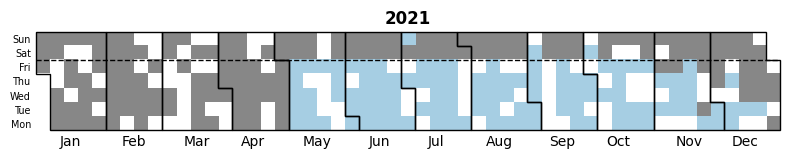


--- Calendar for Configuration 2: KMeans {'n_clusters': 4, 'n_init': 'auto'} ---
cluster_id_weekdays_share [5, 11, 80, 88]
cluster_id_weekend_share [39, 45, 1, 0]
111


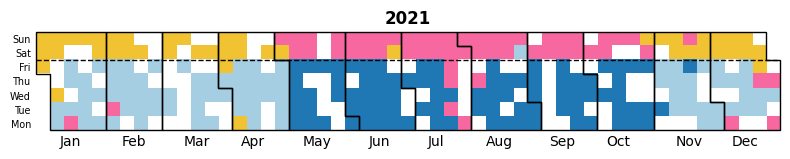


--- Calendar for Configuration 3: AgglomerativeClustering {'n_clusters': 2, 'linkage': 'complete', 'metric': 'manhattan'} ---
cluster_id_weekdays_share [2, 182]
cluster_id_weekend_share [2, 83]
111


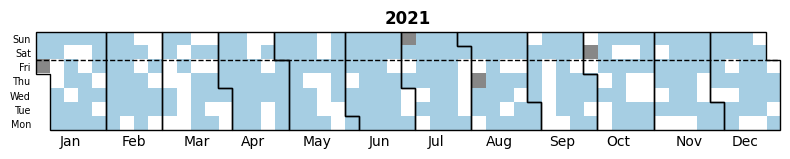


--- Calendar for Configuration 4: AgglomerativeClustering {'n_clusters': 3, 'linkage': 'complete', 'metric': 'manhattan'} ---
cluster_id_weekdays_share [182, 1, 1]
cluster_id_weekend_share [83, 2, 0]
111


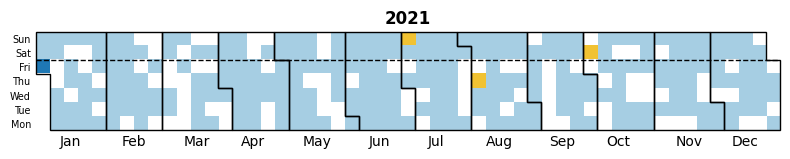


--- Calendar for Configuration 5: BisectingKMeans {'n_clusters': 2} ---
cluster_id_weekdays_share [179, 5]
cluster_id_weekend_share [42, 43]
111


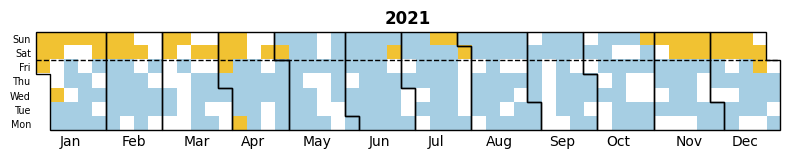


--- Calendar for Configuration 6: BisectingKMeans {'n_clusters': 5} ---
cluster_id_weekdays_share [91, 2, 80, 6, 5]
cluster_id_weekend_share [1, 2, 0, 39, 43]
111


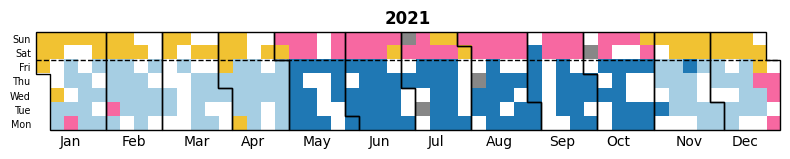


--- Calendar for Configuration 7: DBSCAN {'eps': np.int64(30), 'min_samples': np.int64(2)} ---
cluster_id_weekdays_share [182, 1, 1]
cluster_id_weekend_share [83, 2, 0]
111


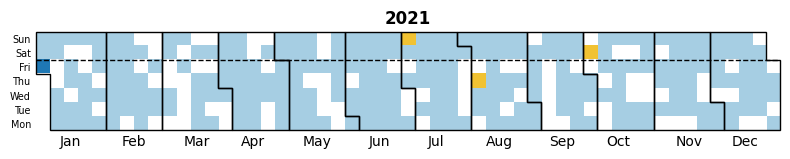


--- Calendar for Configuration 8: GaussianMixture {'n_components': 2, 'covariance_type': 'full'} ---
cluster_id_weekdays_share [76, 108]
cluster_id_weekend_share [82, 3]
111


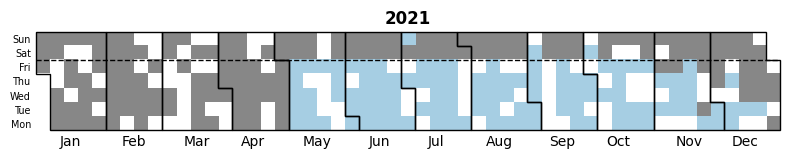


--- Calendar for Configuration 9: GaussianMixture {'n_components': 7, 'covariance_type': 'spherical'} ---
cluster_id_weekdays_share [1, 91, 80, 5, 1, 5, 1]
cluster_id_weekend_share [0, 0, 0, 29, 0, 54, 2]
111


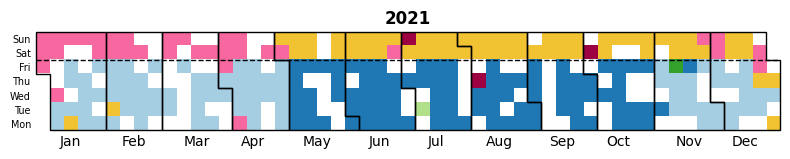

In [ ]:
import numpy as np
from sklearn.cluster import (
    DBSCAN,
    AgglomerativeClustering,
    BisectingKMeans,
    KMeans,
)
from sklearn.mixture import GaussianMixture

for i, config in enumerate(manual_configurations):
    model_name = config["model"]
    params = config["params"]

    print(
        f"\n--- Calendar for Configuration {i+1}: {model_name} {params} ---"
    )

    current_model = None
    raw_labels = None

    try:
        if model_name == "KMeans":
            current_model = KMeans(random_state=0, **params)
            current_model.fit(X_train_scaled)
            raw_labels = current_model.labels_

        elif model_name == "AgglomerativeClustering":
            current_model = AgglomerativeClustering(**params)
            raw_labels = current_model.fit_predict(X_train_scaled)

        elif model_name == "BisectingKMeans":
            current_model = BisectingKMeans(random_state=0, **params)
            current_model.fit(X_train_scaled)
            raw_labels = current_model.labels_

        elif model_name == "DBSCAN":
            current_model = DBSCAN(**params)
            raw_labels = current_model.fit_predict(X_train_scaled)

        elif model_name == "GaussianMixture":
            current_model = GaussianMixture(random_state=0, n_init=5, **params)
            current_model.fit(X_train_scaled)
            raw_labels = current_model.predict(X_train_scaled)

        else:
            print(f"  Skipping unknown model type: {model_name}")
            continue

    except Exception as e:
        print(f"  Error fitting {model_name} with params {params}: {e}")
        continue

    if raw_labels is None:
        print(f"  Could not generate labels for configuration {i+1}.")
        continue

    # Noise management for DBSCAN
    labels_for_viz = np.copy(raw_labels)
    unique_raw_labels = np.unique(raw_labels)
    n_clusters_display = 0

    if -1 in unique_raw_labels:
        actual_clusters = unique_raw_labels[unique_raw_labels != -1]
        n_actual_clusters = len(actual_clusters)

        # Mappa il rumore (-1) come un nuovo cluster separato per la visualizzazione
        labels_for_viz[labels_for_viz == -1] = n_actual_clusters
        n_clusters_display = n_actual_clusters + 1
    else:
        n_clusters_display = len(unique_raw_labels)

    if n_clusters_display == 0:
        print(f"  No valid clusters to display for configuration {i+1}.")
        continue


    days_colors, color_to_cluster, style_to_cluster = assign_colors(
        n_clusters_display, days_train, labels_for_viz
    )

    make_calendar_visualization_figure(
        days_train,
        labels_for_viz,
        n_clusters_display,
        [2021],
        days_colors,
        color_to_cluster,
        save_figure=None,
    )

The conclusion about visualized patterns has been drawn in the final section of this report.

# Part 3: Independent work - clustering evaluation

## Internal evaluation
(sections above)

In [ ]:
print("\nSummary of Clustering Models, Parameters, and Evaluation Metrics:")
print(results_df_sorted.to_string(index=False))


Summary of Clustering Models, Parameters, and Evaluation Metrics:
                  Model                                                      Parameters  Number of Clusters  Silhouette Score  Davies-Bouldin Score  Calinski-Harabasz Score                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

## External evaluation with short-term prediction
According to the advanced track, I gave as input the validation set obtained from the training data.

In [ ]:
# Calculate the total number of NaN values in the evaluation dataset
print('Number of NaNs:', np.sum(np.isnan(X_valid_scaled)))

# Calculate the rate of NaN values in the evaluation dataset
print('Rate of NaNs:', np.sum(np.isnan(X_valid_scaled)) / (len(days_valid) * nintvals))

# Calculate the number of days with missing values
nans_per_day_eval = np.sum(np.isnan(X_valid_scaled), 1)
print('Number of days with missing values:', np.size(np.where(nans_per_day_eval > 0)))

# Filter out days with no missing values and create a new dataset
vectorized_day_dataset_no_nans_eval = X_valid_scaled[np.where(nans_per_day_eval == 0)[0], :]
days_not_nans_eval = days_valid[np.where(nans_per_day_eval == 0)[0]]

# Calculate the final number of days in the evaluation dataset after removing missing values
print('Final number of days in evaluation dataset:', len(days_not_nans_eval))

# Print the list of days in the evaluation dataset with no missing values
print('List of days without missing values:', days_not_nans_eval)

# Calculate the total number of days in the filtered evaluation dataset
ndays_eval_not_nans = len(days_not_nans_eval)

Number of NaNs: 0
Rate of NaNs: 0.0
Number of days with missing values: 0
Final number of days in evaluation dataset: 68
List of days without missing values: [20210227 20210225 20211028 20211023 20210802 20210913 20210116 20211213
 20210308 20210301 20210319 20210321 20210311 20210817 20210423 20210522
 20210128 20211231 20210910 20210208 20210820 20210827 20211210 20210730
 20211101 20211201 20211021 20210323 20211220 20211007 20210419 20210425
 20210310 20210825 20211124 20210630 20210305 20211228 20210625 20210326
 20210513 20210304 20210228 20211020 20210420 20210524 20210603 20211106
 20210122 20210928 20210418 20211001 20210221 20211125 20210525 20211115
 20210629 20210108 20210107 20210313 20211226 20210123 20210523 20210309
 20210417 20210702 20210113 20211016]


So far, we have evaluated our clusters internally using metrics like silhouette score. But how do we know if these discovered "day-types" are actually useful for a real-world task? Do centroids improve one-step-ahead forecasting relative to meaningful baselines?

The idea is simple: if our centroids truly capture meaningful patterns, they should provide a good "baseline" prediction for what traffic will look like in the very near future. We will test this by using the centroids to predict the next 5-minute interval, a common task in traffic management systems.

First, lets load the evaluation dataset used of evaluating short-term prediction accuracy, vectorize it to day vectors and remove missing values.

Now when the dataset for evaluation is ready, below is a script for evaluating short-term prediction performance.

We will implement a specific forecasting strategy:

For each 5-minute interval j in a new day:

1. Look at the recent past: We take the actual observed traffic flow from the last 5 intervals (the last 25 minutes: j-4 to j).

2. Find the best-matching pattern: We compare this short recent history against the beginning of each of our four cluster centroids. The centroid whose first j+1 intervals most closely match the recent past is selected as our "best guide" for what should happen next.

3. Make a prediction: We use the value of the best-matching centroid at the next time interval (j+1) as our prediction.

4. Measure error: We compare this prediction to the actual observed traffic flow at interval j+1 and calculate the error.

We repeat this process for every possible interval in every day in our evaluation set. This tests the centroids' predictive power in a real context.

In [ ]:
# Import the pairwise_distances function from scikit-learn's metrics library
import sklearn.metrics.pairwise as dis_lib

# Define a function to find the closest centroid to a new data point within a specified day-time interval range
def find_the_closest_centroid(centroids, new_day, from_interval: int, to_interval: int):
    closest_centroid = None
    closest_dist = None

    # Slice the new_day for the relevant intervals. new_day is already (1, nintvals)
    # The slice will be (1, num_intervals)
    new_day_slice = new_day[:, from_interval : to_interval + 1]

    # Iterate through each centroid
    for i in range(0, len(centroids)):
        # Reshape centroids[i] to be 2D (1, nintvals) and then slice for the relevant intervals
        # centroids[i] is (nintvals,) so slicing it gives (num_intervals,)
        # then reshape to (1, num_intervals)
        centroid_slice = centroids[i][from_interval : to_interval + 1].reshape(1, -1)

        # Calculate the Euclidean distance between the sliced centroid and the sliced new data point
        ed_t = dis_lib.paired_distances(centroid_slice, new_day_slice, metric='euclidean')

        # Check if the current centroid is closer than the previously closest one
        if closest_centroid is None or closest_dist > ed_t:
            closest_centroid = i
            closest_dist = ed_t

    return closest_centroid


In [ ]:
import re

all_models_prediction_results = []

for index, row in results_df_sorted.iterrows():

        model_name = row['Model']
        params_str = row['Parameters']

        # Initialize a list to store centroid data for the current model
        centroids = []

        # Extract labels as a string and parse it into a numpy array
        labels_str = row['Labels']
        # Use regex to find all numbers (including negative for potential -1 noise labels) and convert to int
        labels_array = np.array([int(x) for x in re.findall(r'-?\d+', labels_str)])

        # Determine the number of clusters (excluding noise label -1 if present)
        unique_labels = np.unique(labels_array)
        if -1 in unique_labels:
            unique_labels = unique_labels[unique_labels != -1]

        # Calculate centroids for each cluster of the current model
        for cluster_id in unique_labels:
            # Get indices of data points belonging to the current cluster
            cluster_indices = np.where(labels_array == cluster_id)[0]
            # Calculate the mean of X_train_scaled for these data points
            centroid = np.nanmean(X_train_scaled[cluster_indices, :], axis=0).reshape(1, nintvals)
            centroids.append(centroid)

        # Define the number of past intervals to consider for classification
        n_past_intervals_for_classification = 5

        # Initialize variables to calculate accuracy metrics for the current model
        total_mae = 0
        total_mape = 0
        mape_counts = 0
        prediction_counts = 0

        # Loop through each day in the validation dataset with no missing values
        for i in range(0, ndays_eval_not_nans):
            # Loop through intervals from n_past_intervals_for_classification to nintvals - 1
            for j in range(n_past_intervals_for_classification, nintvals - 1):
                # Find the closest centroid for the current data point
                centroid_index = find_the_closest_centroid(
                    centroids,
                    X_valid_scaled[i].reshape(1, nintvals), # Using X_valid_scaled as per the original cell's context
                    j - n_past_intervals_for_classification,
                    j
                )

                # Predict the value for the next interval
                predicted_value = centroids[centroid_index][0, j + 1]

                # Calculate Mean Absolute Error (MAE) and Mean Absolute Percentage Error (MAPE)
                actual_val = X_valid_scaled[i][j + 1]
                mae_t = abs(predicted_value - actual_val)
                total_mae += mae_t

                # MAPE just for data different from 0
                if actual_val != 0:
                  mape_t = abs(predicted_value - actual_val) / abs(actual_val)
                  total_mape += mape_t
                  mape_counts += 1

                prediction_counts += 1

        # Store the prediction accuracy metrics for the current model
        current_model_results = {
            'Model': model_name,
            'Parameters': params_str,
            'MAE': total_mae / prediction_counts if prediction_counts > 0 else np.nan,
            'MAPE': total_mape / mape_counts if mape_counts > 0 else np.nan
        }
        all_models_prediction_results.append(current_model_results)

for result in all_models_prediction_results:
    print(f"Model: {result['Model']}, Parameters: {result['Parameters']}")
    print(f"  MAE: {result['MAE']:.4f}")
    print(f"  MAPE: {result['MAPE']:.4f}")
    print("--------------------------------------------------")


Model: DBSCAN, Parameters: {'eps': np.int64(30), 'min_samples': np.int64(2)}
  MAE: 0.7744
  MAPE: 1.2854
--------------------------------------------------
Model: AgglomerativeClustering, Parameters: {'n_clusters': 2, 'linkage': 'complete', 'metric': 'manhattan'}
  MAE: 0.7744
  MAPE: 1.2854
--------------------------------------------------
Model: AgglomerativeClustering, Parameters: {'n_clusters': 3, 'linkage': 'complete', 'metric': 'manhattan'}
  MAE: 0.7744
  MAPE: 1.2854
--------------------------------------------------
Model: BisectingKMeans, Parameters: {'n_clusters': 2}
  MAE: 0.6555
  MAPE: 2.1189
--------------------------------------------------
Model: KMeans, Parameters: {'n_clusters': 2, 'n_init': 'auto'}
  MAE: 0.6419
  MAPE: 3.4603
--------------------------------------------------
Model: GaussianMixture, Parameters: {'n_components': 2, 'covariance_type': 'full'}
  MAE: 0.6419
  MAPE: 3.4603
--------------------------------------------------
Model: GaussianMixture, Par

Despite the generally low quantitative performance across all evaluated models, the final model selection was guided by a holistic approach combining internal and external evaluation metrics, domain expertise, and calendar-based visualizations. While metrics such as the Silhouette Score initially favored  DBSCAN and Agglomerative Clustering, the calendar-based spatial distribution revealed significant limitations in these choices. Specifically, both models yielded imbalanced clusters with limited domain interpretability. Consequently, kMeans with k = 4 was selected as the optimal model. Although its internal metrics (Silhouette Score) and prediction errors (MAPE) appear modest, it provides a significantly more balanced cluster distribution and superior  interpretability. The calendar visualization confirms that the four clusters successfully capture two fundamental underlying dimensions of the traffic dynamics: day type (weekdays vs. weekends) and seasonality (warm vs. cold months):

1. Cluster 1: Weekdays during the warmer period (May–October)
2. Cluster 2: Weekdays during the colder period (November–April)
3. Cluster 3: Weekends during the warmer period (May–October)
4. Cluster 4: Weekends during the colder period (November–April)

In [ ]:
final_model = KMeans(n_clusters=4, random_state=0, n_init="auto")
final_model.fit(X_train_scaled)
final_labels = final_model.labels_

NameError: name 'KMeans' is not defined

# Final evaluation on test set
Dataset preparation

In [ ]:
# Read the evaluation dataset from a CSV file
data_eval_df = pd.read_csv("evaluation_dataset_exercise_5_clustering_highway_traffic.csv", sep=";")

# Sort the evaluation DataFrame by columns "Date" and "Interval_5"
data_eval_df.sort_values(["Date", "Interval_5"])

# Extract unique dates from the sorted evaluation DataFrame
days_eval = np.unique(data_eval_df[['Date']].values.ravel())
# Calculate the total number of unique days in the evaluation dataset
ndays_eval = len(days_eval)

# Group the evaluation DataFrame by the "Date" column
day_eval_subsets_df = data_eval_df.groupby(["Date"])

# Initialize a matrix 'vectorized_day_dataset_eval' filled with NaN values
vectorized_day_dataset_eval = np.zeros((ndays_eval, nintvals))
vectorized_day_dataset_eval.fill(np.nan)
# This section initializes a 2D array to store the evaluation dataset and fills it with NaN values.

# Loop through each unique day in the evaluation dataset
for i in range(0, ndays_eval):
    # Get the DataFrame corresponding to the current day
    df_t = day_eval_subsets_df.get_group(days_eval[i])

    # Loop through each row in the current day's DataFrame
    for j in range(len(df_t)):
        # Get the current day's DataFrame (this line is redundant)
        df_t = day_eval_subsets_df.get_group(days_eval[i])

        # Extract the "Interval_5" and "flow" values and populate 'vectorized_day_dataset_eval'
        vectorized_day_dataset_eval[i, df_t.iloc[j]["Interval_5"]] = df_t.iloc[j]["flow"]

# Print the resulting 'vectorized_day_dataset_eval'
print(vectorized_day_dataset_eval)

/tmp/ipykernel_742/3223714943.py:23: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  df_t = day_eval_subsets_df.get_group(days_eval[i])
/tmp/ipykernel_742/3223714943.py:28: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  df_t = day_eval_subsets_df.get_group(days_eval[i])


[[35. 29. 32. ... 62. 66. 71.]
 [44. 44. 51. ... 30. 31. 23.]
 [21. 22. 17. ... 20. 22. 22.]
 ...
 [17. 17. 20. ... 35. 25. 27.]
 [37. 25. 30. ... 37. 36. 49.]
 [42. 28. 32. ... 45. 49. 38.]]


In [ ]:
# Calculate the total number of NaN values in the evaluation dataset
print('Number of NaNs:', np.sum(np.isnan(vectorized_day_dataset_eval)))

# Calculate the rate of NaN values in the evaluation dataset
print('Rate of NaNs:', np.sum(np.isnan(vectorized_day_dataset_eval)) / (ndays_eval * nintvals))

# Calculate the number of days with missing values
nans_per_day_eval = np.sum(np.isnan(vectorized_day_dataset_eval), 1)
print('Number of days with missing values:', np.size(np.where(nans_per_day_eval > 0)))

# Filter out days with no missing values and create a new dataset
vectorized_day_dataset_no_nans_eval = vectorized_day_dataset_eval[np.where(nans_per_day_eval == 0)[0], :]
days_not_nans_eval = days_eval[np.where(nans_per_day_eval == 0)[0]]

# Calculate the final number of days in the evaluation dataset after removing missing values
print('Final number of days in evaluation dataset:', len(days_not_nans_eval))

# Print the list of days in the evaluation dataset with no missing values
print('List of days without missing values:', days_not_nans_eval)

# Calculate the total number of days in the filtered evaluation dataset
ndays_eval_not_nans = len(days_not_nans_eval)

Number of NaNs: 96
Rate of NaNs: 0.004166666666666667
Number of days with missing values: 11
Final number of days in evaluation dataset: 69
List of days without missing values: [20220108 20220109 20220131 20220204 20220209 20220210 20220211 20220223
 20220226 20220227 20220302 20220304 20220305 20220306 20220310 20220314
 20220315 20220321 20220323 20220326 20220403 20220406 20220416 20220418
 20220421 20220422 20220425 20220427 20220428 20220503 20220505 20220514
 20220519 20220521 20220522 20220526 20220530 20220601 20220603 20220609
 20220616 20220619 20220623 20220628 20220704 20220711 20220712 20220904
 20220910 20220911 20220920 20220921 20220925 20220927 20220929 20220930
 20221005 20221022 20221024 20221114 20221116 20221121 20221122 20221213
 20221216 20221218 20221220 20221223 20221230]


In [ ]:
X_test_scaled = scaler.transform(vectorized_day_dataset_no_nans_eval)
print(X_test_scaled)

[[ 0.1126456  -0.25869031 -0.03861146 ...  1.48223938  1.76888075
   2.34304681]
 [ 0.68921009  0.72883609  1.20254067 ... -0.32244472 -0.24466202
  -0.629678  ]
 [-0.7842325  -0.71953596 -1.01846841 ... -0.8864085  -0.76243016
  -0.69160977]
 ...
 [-1.04048338 -1.04871143 -0.82249702 ... -0.04046283 -0.58984078
  -0.38195093]
 [ 0.24077105 -0.52203068 -0.16925906 ...  0.07232993  0.04298695
   0.98054794]
 [ 0.56108465 -0.3245254  -0.03861146 ...  0.52350095  0.79087426
   0.2992985 ]]


In [ ]:
final_labels_test = final_model.predict(X_test_scaled)
print(final_labels_test)

[0 0 2 2 2 2 2 2 0 0 2 2 0 0 2 2 2 2 2 0 1 3 1 1 3 3 3 3 3 3 3 1 3 1 1 1 3
 3 3 3 3 1 3 3 3 3 1 1 1 1 3 3 1 3 3 3 3 1 3 1 2 1 1 1 1 0 2 1 1]


cluster_id_weekdays_share [0, 10, 15, 25]
cluster_id_weekend_share [8, 11, 0, 0]
111


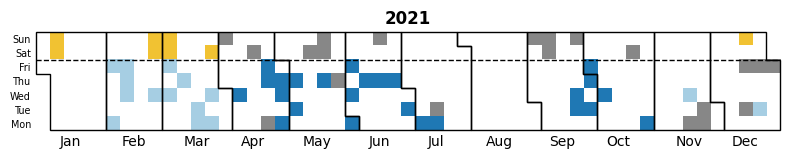

In [ ]:
n_clusters_t = len(np.unique(final_labels_test))
days_colors, color_to_cluster, style_to_cluster = assign_colors(n_clusters_t, days_not_nans_eval, final_labels_test)
make_calendar_visualization_figure(days_not_nans_eval, final_labels_test, n_clusters_t, [2021], days_colors,
                                   color_to_cluster, save_figure=None)

In [ ]:
import re

# Retrieve centroids from the final_model
centroids = final_model.cluster_centers_

# Define the number of past intervals to consider for classification
n_past_intervals_for_classification = 5

# Initialize variables to calculate accuracy metrics
total_mae = 0
total_mape = 0
mape_counts = 0
prediction_counts = 0

# Loop through each day in the evaluation dataset (X_test_scaled)
# ndays_eval_not_nans is the count of days in X_test_scaled
for i in range(0, ndays_eval_not_nans):
    # Loop through intervals from n_past_intervals_for_classification to nintvals - 1
    for j in range(n_past_intervals_for_classification, nintvals - 1):
        # Find the closest centroid for the current data point in X_test_scaled
        centroid_index = find_the_closest_centroid(
            centroids,
            X_test_scaled[i].reshape(1, nintvals),
            j - n_past_intervals_for_classification,
            j
        )

        # Predict the value for the next interval
        predicted_value = centroids[centroid_index][j + 1]

        # Calculate Mean Absolute Error (MAE) and Mean Absolute Percentage Error (MAPE)
        actual_val = X_test_scaled[i][j + 1]
        mae_t = abs(predicted_value - actual_val)
        total_mae += mae_t

        # MAPE only for data different from 0
        if actual_val != 0:
            mape_t = abs(predicted_value - actual_val) / abs(actual_val)
            total_mape += mape_t
            mape_counts += 1

        prediction_counts += 1

# Calculate and print the prediction accuracy metrics for the final model
print(f"  MAE: {total_mae / prediction_counts if prediction_counts > 0 else np.nan:.4f}")
print(f"  MAPE: {total_mape / mape_counts if mape_counts > 0 else np.nan:.4f}")


Risultati di predizione per il modello finale:
  MAE: 0.4575
  MAPE: 2.6158


The clustering pipeline was successfully applied to the new data, with new observations being correctly mapped to the previously identified cluster centroids. However, performance evaluation on the new dataset yielded relatively high values for both Mean Absolute Error (MAE) and Mean Absolute Percentage Error (MAPE).